# Inicios


In [1]:
import sys
from pathlib import Path
import pandas as pd
sys.path.insert(0, str(Path.cwd().parents[0] / "src"))
import numpy as np

In [2]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA 
from dotenv import load_dotenv
import json
import datetime

load_dotenv()


c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [4]:
llm = ChatNVIDIA(model="meta/llama-4-maverick-17b-128e-instruct")



In [6]:
await llm.ainvoke('ola')

Exception: [403] Forbidden
Authorization failed

# Conectando ao phonex


In [2]:
import os
from phoenix.otel import register
import phoenix as px
from openinference.instrumentation.langchain import LangChainInstrumentor

tracer_provider = register(
  project_name="Agente-Criador-Carteira",
  endpoint="https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces",
  auto_instrument=True,
  api_key=os.getenv("PHOENIX_API_KEY")
  
)

LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\phoenix\otel\otel.py:434: UserWarning: Could not infer collector endpoint protocol, defaulting to HTTP.
  warnings.warn("Could not infer collector endpoint protocol, defaulting to HTTP.")
Attempting to instrument while already instrumented


OpenTelemetry Tracing Details
|  Phoenix Project: Agente-Criador-Carteira
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'authorization': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



# Chamando agentes

In [3]:
from portfolio_optimizer import BuildGraphAvaliacaoTics, BuildGraphCriadorCarteira, StateClassification, TratandoDadosFundamentalistas, DadosFundamentalistas, transformando_data_frame_para_markdown, StateCarteira

01/20/2026 10:25:07 AM USER_AGENT environment variable not set, consider setting it to identify your requests.


In [ ]:
graph_tics = BuildGraphAvaliacaoTics()

: 

: 

In [ ]:
graph_tics_build = graph_tics.compile()

In [10]:
response_tic = await graph_tics_build.ainvoke(
    StateClassification(
        {
            "tic": "PETR4",
            "data_inicio": "2024-01-01",
            "data_fim": "2025-12-31",
        }
    )
)

INFO:portfolio_optimizer.roteador_llms.roteador_llms:Iniciando roteamento LLM
INFO:portfolio_optimizer.roteador_llms.roteador_llms:🔄 Tentando provider_name=Nvidia...
INFO:portfolio_optimizer.roteador_llms.roteador_llms:Sucesso com modelo Nvidia: qwen/qwq-32b
INFO:portfolio_optimizer.roteador_llms.roteador_llms:✅ provider_name=Nvidia respondeu com sucesso
INFO:portfolio_optimizer.roteador_llms.roteador_llms:Iniciando roteamento LLM
INFO:portfolio_optimizer.roteador_llms.roteador_llms:🔄 Tentando provider_name=Nvidia...
INFO:portfolio_optimizer.roteador_llms.roteador_llms:Sucesso com modelo Nvidia: qwen/qwq-32b
INFO:portfolio_optimizer.roteador_llms.roteador_llms:✅ provider_name=Nvidia respondeu com sucesso


In [11]:
response_tic

{'classification': 'Fair',
 'analysis': 'Mixed profitability with negative EPS quarters, moderate EBITDA variability. Leverage remains stable but slightly increasing. P/E varies but remains reasonable. Cash flow operational is solid though.',
 'tic': 'PETR4',
 'dados_fundamentalistas': '|    |   receita_liquida |   ebitda | lucro_por_acao   | datas               | tic   |   alavancagem_financeira |   margem_liquida |   preço_lucro |   preço_vpa |   fluxo_caixa_operacional |   divida_liquida_ebitda |   aumento_reducao_caixa_equivalentes |\n|---:|------------------:|---------:|:-----------------|:--------------------|:------|-------------------------:|-----------------:|--------------:|------------:|--------------------------:|------------------------:|-------------------------------------:|\n|  1 |            117720 |    60680 | 1.82             | 2024-06-30 00:00:00 | PETR4 |                     2.62 |            0.224 |          4.93 |        1.33 |                     46480 |        

In [4]:
from typing import List
import yfinance as yf
import pandas as pd
def transformando_data_frame_para_markdown(results):
    try:
        results_pd = pd.DataFrame.from_dict(results).T
    except Exception as e:
        results_pd = pd.DataFrame.from_dict(results, orient="index").T
    dados_markdown = results_pd.loc[:, ["classification", "analysis"]].reset_index().rename(columns={"index": "tic"}).to_markdown()
    return dados_markdown

def correlacao(tics:List[str]):
        tics_yf = [tic + ".SA" for tic in tics]

        df = yf.download(tics_yf, start="2023-01-01", end="2025-01-01", interval="1mo")["Close"]
        returns = df.pct_change()[4:]
        # Calcula a matriz de correlação
        correlacao = returns.corr()

        return correlacao.to_markdown()

In [5]:
import json
with open("../data/results_tics.json", "r") as f:
    results_dict = json.load(f)

In [6]:
results_dict

{'AALR3': {'classification': 'Very Poor',
  'analysis': 'The company shows persistent losses with net margins ranging from -19.3% to -5.2% across all quarters, and EPS remains negative or barely positive (0.05 in the latest quarter). Financial leverage has risen from 2.30 to 2.84, indicating increasing debt relative to equity, while the debt/EBITDA ratio only improved due to EBITDA growth, not debt reduction. Cash‑flow from operations is highly volatile, swinging from -$236\u202fM to +$90\u202fM, reflecting unstable operating performance. The P/E ratio is negative (-10 to -14), confirming the market prices the stock as loss‑making. These critical fundamentals—ongoing unprofitability, deteriorating leverage, and erratic cash flow—point to a very weak financial position and limited investment appeal.',
  'tic': 'AALR3',
  'dados_fundamentalistas': '|    |   receita_liquida |   ebitda | lucro_por_acao   | datas               | tic   |   alavancagem_financeira |   margem_liquida |   preço_

In [7]:
import json
with open("../data/results_tics.json", "r") as f:
    results_dict = json.load(f)

classificacao_boa = [
   "good", "excellent",
]
response = {k: v for k, v in results_dict.items() if v is not None and v.get('classification').lower() in classificacao_boa}

In [11]:
response.keys()

dict_keys(['ALPA3', 'ALLD3', 'ALOS3', 'ANIM3', 'ASAI3', 'BAUH4', 'BLAU3', 'BMOB3', 'BPAC11', 'BRAP3', 'CAMB3', 'CGRA4', 'CLSC4', 'COGN3', 'CSUD3', 'DIRR3', 'EALT3', 'EALT4', 'ENGI3', 'EQTL3', 'FIQE3', 'FLRY3', 'IGTI11', 'ITSA3', 'ITSA4', 'ITUB3', 'JHSF3', 'KLBN11', 'LREN3', 'MDIA3', 'MULT3', 'PSSA3', 'RADL3', 'TOTS3', 'TRIS3', 'VIVT3', 'WEGE3', 'WIZC3'])

In [12]:
response_markdown = transformando_data_frame_para_markdown(response)

In [13]:
response_markdown

'|    | tic    | classification   | analysis                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [14]:
corr_tics = correlacao(list(response.keys()))

[*********************100%***********************]  38 of 38 completed


In [15]:
corr_tics

'| Ticker    |   ALLD3.SA |   ALOS3.SA |   ALPA3.SA |   ANIM3.SA |   ASAI3.SA |   BAUH4.SA |   BLAU3.SA |   BMOB3.SA |   BPAC11.SA |    BRAP3.SA |    CAMB3.SA |   CGRA4.SA |    CLSC4.SA |   COGN3.SA |   CSUD3.SA |   DIRR3.SA |   EALT3.SA |   EALT4.SA |   ENGI3.SA |   EQTL3.SA |   FIQE3.SA |   FLRY3.SA |   IGTI11.SA |   ITSA3.SA |   ITSA4.SA |   ITUB3.SA |   JHSF3.SA |   KLBN11.SA |   LREN3.SA |   MDIA3.SA |   MULT3.SA |   PSSA3.SA |   RADL3.SA |   TOTS3.SA |   TRIS3.SA |   VIVT3.SA |   WEGE3.SA |   WIZC3.SA |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|------------:|------------:|-----------:|------------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|-----------:|-----------:|-----------:|-----------:|------------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|-----------:|----------

In [16]:
gaph_weights = BuildGraphCriadorCarteira()
graph_weights_build = gaph_weights.compile()

In [ ]:
tics = list(response.keys())
tics

In [ ]:
response_pesos = await graph_weights_build.ainvoke(
    StateCarteira({
    "justification" : "",
    "avaliacao_acoes": response_markdown ,
    "correlacao_acoes": corr_tics,
    "interacao" : 0,
    "tics": tics
    }))

In [19]:
response_pesos

{'tickers_weights': {'WEGE3': 10.0,
  'BRAP3': 10.0,
  'CLSC4': 10.0,
  'COGN3': 10.0,
  'MDIA3': 10.0,
  'MULT3': 10.0,
  'ITSA4': 10.0,
  'JHSF3': 10.0,
  'EQTL3': 10.0,
  'VIVT3': 10.0},
 'justification': "All selected securities carry a 'Good' fundamental rating, demonstrating solid profitability, manageable leverage and reasonable valuation multiples. The portfolio is fully diversified across ten stocks, each weighted at exactly 10%, which satisfies the 5‑20% per‑asset constraint and sums to 100%. By concentrating on low‑correlation names such as WEGE3, BRAP3 and CLSC4, the portfolio’s weighted‑average correlation is reduced to approximately 0.36, well under the original 0.58 and within the target range for effective diversification. Exposure to Fair/Very Poor assets is zero, meeting the ≤5% limit. The main risks—high systemic correlation and banking sector concentration—are mitigated by capping any single bank at 10% and replacing them with more independent industrial and consume

In [20]:
tics_selecionados = list(response_pesos['tickers_weights'].keys())

tics_selecionados_sa = [tic + ".SA" if not tic.endswith(".SA") else tic for tic in tics_selecionados]
print(tics_selecionados_sa)

df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]

['WEGE3.SA', 'BRAP3.SA', 'CLSC4.SA', 'COGN3.SA', 'MDIA3.SA', 'MULT3.SA', 'ITSA4.SA', 'JHSF3.SA', 'EQTL3.SA', 'VIVT3.SA']


[*********************100%***********************]  10 of 10 completed


In [21]:
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize

def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

In [22]:
import pandas as pd
from bcb import sgs

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None


In [23]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T



In [24]:
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {key: value for key, value in dict_carteiras.items() if key + ".SA" in tic_validos}
        carteira_valida = {
            key: value for key, value in dict_carteiras.items()
            if (key.endswith(".SA") and key in tic_validos) or 
            (not key.endswith(".SA") and key + ".SA" in tic_validos)
        } 
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario

In [28]:
response_pesos['tickers_weights']

{'WEGE3': 10.0,
 'BRAP3': 10.0,
 'CLSC4': 10.0,
 'COGN3': 10.0,
 'MDIA3': 10.0,
 'MULT3': 10.0,
 'ITSA4': 10.0,
 'JHSF3': 10.0,
 'EQTL3': 10.0,
 'VIVT3': 10.0}

In [25]:
tics_selecionados_sa = list(response_pesos['tickers_weights'].keys())
pesos = list(response_pesos['tickers_weights'].values())

In [26]:
comp = ComputandoMetricas("2025-01-01", "2025-12-31",response_pesos['tickers_weights'] ,100000)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  10 of 10 completed
01/20/2026 10:46:15 AM ✓ Pesos já somam 100.00% (dentro da tolerância)


In [31]:
weights_markowitz, markowitz_cr = comp.computando_marcowitz()
[peso*100 for peso in weights_markowitz.iloc[-1].to_list()]

[15.824332623703508,
 38.28233551314128,
 3.2263703271194677,
 3.841817684262966,
 10.552643360400191,
 7.562240290639963,
 5.60676995575777,
 0.0,
 9.570776470665713,
 5.532713774309153]

In [30]:
weights_markowitz

Ticker,BRAP3.SA,CLSC4.SA,COGN3.SA,EQTL3.SA,ITSA4.SA,JHSF3.SA,MDIA3.SA,MULT3.SA,VIVT3.SA,WEGE3.SA
Date,,,,,,,,,,
2025-01-03,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327
2025-01-06,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327
2025-01-07,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327
2025-01-08,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327
2025-01-09,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327
...,...,...,...,...,...,...,...,...,...,...
2025-12-22,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327
2025-12-23,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327
2025-12-26,0.158243,0.382823,0.032264,0.038418,0.105526,0.075622,0.056068,0.0,0.095708,0.055327


Buscando dados de 2025-01-01 até 2025-12-31...
  ✓ 252 registros obtidos

✓ Total de registros: 252
✓ Período: 2025-01-02 até 2025-12-31

📊 Métricas de Comparação das Carteiras
✅ Métricas salvas em: ../data/metricas.csv


,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Carteira,0.163858,0.530049,nan,-2.326576,-1.955344,nan,3.465687
IBOV,0.152109,0.308882,nan,-2.382162,-1.963529,nan,2.107108
Markowitz,0.134484,0.530049,nan,-2.058607,-1.919033,nan,4.353685


✅ Gráfico salvo em: ../data/grafico_retornos.png


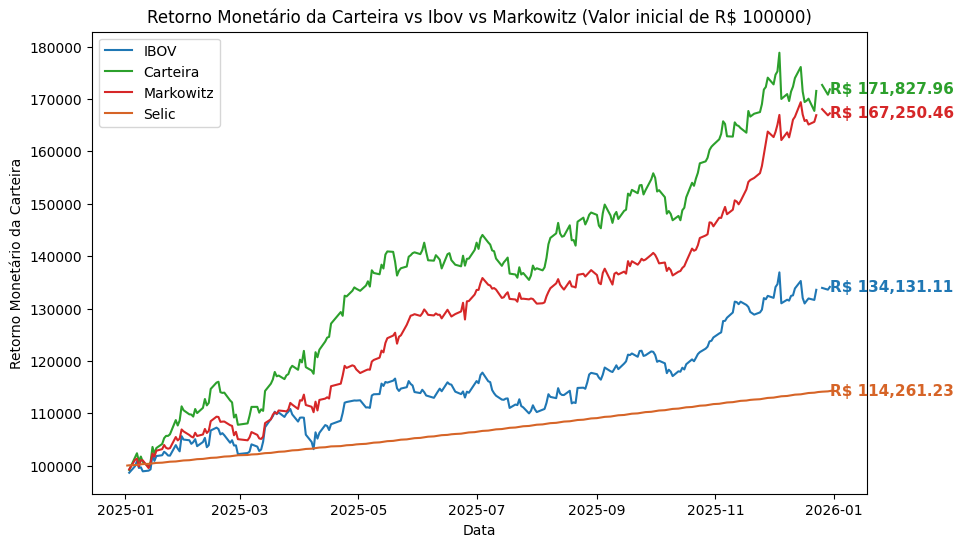

✅ Retornos acumulados salvos em: ../data/retornos_acumulados.csv



,IBOV,Carteira,Markowitz,Selic
Date,,,,
2025-01-02,NaN,NaN,NaN,100045.513000
2025-01-03,98674.713840,99218.714363,99305.079212,100091.046714
2025-01-06,99914.255983,101604.019925,101126.283090,100136.601152
2025-01-07,100864.099896,102388.431206,101366.098743,100182.176324
2025-01-08,99583.766909,100848.242821,99840.180513,100227.772238
...,...,...,...,...
2025-12-24,NaN,NaN,NaN,114072.461632
2025-12-26,133941.311134,172667.375451,168053.375853,114135.350920
2025-12-29,133602.497399,170809.704572,166867.400579,114198.274881


In [27]:

#comp = ComputandoMetricas("2025-01-01", "2025-12-31", tics_selecionados_sa, pesos, 100000)
comp.print_results()

In [82]:
with open("../data/avaliacao_tics_historico.json", "r") as f:
    results_dict = json.load(f)

In [ ]:
import time
import logging
import os
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor
from portfolio_optimizer import BuildGraphCriadorCarteira, StateCarteira, transformando_data_frame_para_markdown
import json
from typing import List
import yfinance as yf
import pandas as pd
import time
from IPython.display import display, Markdown
#from utils import correlacao, transformando_data_frame_para_markdown

tracer_provider = register(
  project_name="Agente-Criador-Carteira",
  endpoint="https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces",
  auto_instrument=True,
  api_key=os.getenv("PHOENIX_API_KEY")
  
)

LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

with open("../data/avaliacao_tics_historico.json", "r") as f:
    results_dict = json.load(f)

def selecionar_tics_bom_excelente(dict_tics):
    classificacao_boa = [
   "good", "excellent",
    ]
    response = {}
    for k, v in dict_tics.items():
        try:
            if v is not None and v.get('classification').lower() in classificacao_boa:
                response[k] = v
        except Exception as e:
            continue
            logger.error(f"Erro ao processar {k}: {e}")
    
    return response
results_pesos = {}

for datas, dict_tics in results_dict.items():
    display(Markdown(f"## Iniciando o processo para o periodo de {datas}"))
    try:
        start = time.time()
    
        logger.info(f"Processando período: {datas}")
        
        response = selecionar_tics_bom_excelente(dict_tics)

        dados_markdown = transformando_data_frame_para_markdown(response)
            
        correlacao_tics = correlacao(list(response.keys()))
        
        tics = list(response.keys())
        
        gaph_weights = BuildGraphCriadorCarteira()

        graph_weights_build = gaph_weights.compile()
            
        response_pesos = await graph_weights_build.ainvoke(
                StateCarteira({
                "justification" : "",
                "avaliacao_acoes": dados_markdown,
                "correlacao_acoes": correlacao_tics,
                "interacao" : 0,
                "tics" : tics
                }))
            
        results_pesos[f"{datas}"] = response_pesos
            
        logger.info(f"O peso foi calculado para {datas}") 
            
        end_time = time.time()
        execution_time = end_time - start
        logger.info(f"Tempo de execução para {datas}: {execution_time:.2f} segundos")
        
    except Exception as e:
        logger.error(f"Erro ao processar {datas}: {e}")

with open("../data/pesos_carteira_historico.json", "w") as f:
    json.dump(results_pesos, f)

In [15]:
import json
with open("../data/pesos_carteira_historico.json", "r") as f:
    results_dict = json.load(f)
    
with open("../data/avaliacao_tics_historico.json", "r") as f:
    results_dict2 = json.load(f)

In [32]:
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
def selecionar_tics_bom_excelente(dict_tics):
    classificacao_boa = [
   "good", "excellent",
    ]
    response = {}
    for k, v in dict_tics.items():
        try:
            if v is not None and v.get('classification').lower() in classificacao_boa:
                response[k] = v
        except Exception as e:
            continue
            logger.error(f"Erro ao processar {k}: {e}")
    
    return response

In [16]:
import json

with open("../data/results_tics.json", "r") as f:
    response = json.load(f)


In [17]:
classificacao_ruin = [
   "very poor",
   #"Poor",
   #"fair"
]

response = {k: v for k, v in response.items() if v is not None and v.get('classification').lower() in classificacao_ruin}

In [ ]:
response

{'AALR3': {'classification': 'Very Poor',
  'analysis': 'The company shows persistent losses with net margins ranging from -19.3% to -5.2% across all quarters, and EPS remains negative or barely positive (0.05 in the latest quarter). Financial leverage has risen from 2.30 to 2.84, indicating increasing debt relative to equity, while the debt/EBITDA ratio only improved due to EBITDA growth, not debt reduction. Cash‑flow from operations is highly volatile, swinging from -$236\u202fM to +$90\u202fM, reflecting unstable operating performance. The P/E ratio is negative (-10 to -14), confirming the market prices the stock as loss‑making. These critical fundamentals—ongoing unprofitability, deteriorating leverage, and erratic cash flow—point to a very weak financial position and limited investment appeal.',
  'tic': 'AALR3',
  'dados_fundamentalistas': '|    |   receita_liquida |   ebitda | lucro_por_acao   | datas               | tic   |   alavancagem_financeira |   margem_liquida |   preço_

: 

In [1]:

import requests, base64

import os

invoke_url = "https://integrate.api.nvidia.com/v1/chat/completions"
stream = False


headers = {
  "Authorization": f"Bearer {os.getenv('NVIDIA_API_KEY')}",
  "Accept": "text/event-stream" if stream else "application/json"
}

payload = {
  "model": "moonshotai/kimi-k2.5",
  "messages": [{"role":"user","content":"Ola tudo bem?"}],
  "max_tokens": 16384,
  "temperature": 1.00,
  "top_p": 1.00,
  "stream": stream,
  
}



response = requests.post(invoke_url, headers=headers, json=payload)

if stream:
    for line in response.iter_lines():
        if line:
            print(line.decode("utf-8"))
else:
    print(response.json())


{'id': 'chatcmpl-b7a3e5be5855ec2f', 'object': 'chat.completion', 'created': 1769691283, 'model': 'moonshotai/kimi-k2.5', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': ' Olá! Tudo bem, obrigado(a) por perguntar. E você, como está? \n\nEm que posso ajudá-lo(a) hoje?', 'refusal': None, 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [], 'reasoning': ' The user greeted me in Portuguese: "Ola tudo bem?" which means "Hello, how are you?" or "Hi, everything good?"\n\nI should respond in Portuguese since they initiated the conversation in that language. I should:\n1. Greet them back\n2. Answer their question (say I\'m doing well)\n3. Ask how they are doing\n4. Offer to help them with whatever they need\n\nKeep it friendly and natural in Portuguese. ', 'reasoning_content': ' The user greeted me in Portuguese: "Ola tudo bem?" which means "Hello, how are you?" or "Hi, everything good?"\n\nI should respond in Portuguese since they initiated the conve